## Clients(DT1~DT) 데이터셋 로드

In [1]:
import sys
import os

sys.path.append(
    os.path.abspath("../src")
)

from data.dataset import load_all_clients

datasets = load_all_clients(
    "../data/raw"
)

print(datasets.keys())

dict_keys(['DT1', 'DT2', 'DT3'])


## 전체 데이터셋 비교

### 규모 비교

In [2]:
from data.dataset import load_all_clients
from analysis.compare import *


display(
    compare_clients(datasets)
    )

,Client,Total Cars,Parking Cars,Non Parking Cars,Slots,Timeline Rows,Duration(H)
0,DT1,17084,528,16556,20,1790789,15.15
1,DT2,27027,826,26201,20,2847371,24.00
2,DT3,53407,1683,51724,20,5703852,48.00


### 체류시간 비교

In [3]:
display(
    compare_duration(datasets)
) 

,Client,Avg Duration,Median Duration,Max Duration,Min Duration
0,DT1,1923.59,1808.99,3668.02,23.99
1,DT2,2037.50,1812.01,3689.02,602.93
2,DT3,1989.98,1811.02,4698.03,602.00


### 수요비교

In [4]:
display(
    compare_demand(datasets)
)

,Client,Avg Arrival,Peak Arrival,Peak Time
0,DT1,93.87,108,2026-03-24 08:50:00
1,DT2,93.84,125,2026-03-25 00:00:00
2,DT3,92.72,127,2026-03-26 00:00:00


### 슬롯비교

In [5]:
display(
    compare_slots(datasets)
)

,Client,Slot Count,Most Used Slot,Usage Count
0,DT1,20,A000,52994
1,DT2,20,A005,84388
2,DT3,20,A001,168498


In [6]:
compare_clients(datasets).style.background_gradient()

,Client,Total Cars,Parking Cars,Non Parking Cars,Slots,Timeline Rows,Duration(H)
0,DT1,17084,528,16556,20,1790789,15.150000
1,DT2,27027,826,26201,20,2847371,24.000000
2,DT3,53407,1683,51724,20,5703852,48.000000


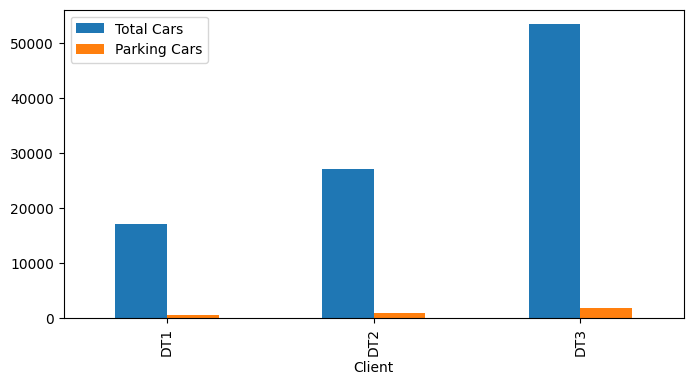

In [7]:
import matplotlib.pyplot as plt

compare_clients(datasets).set_index("Client")[
    ["Total Cars", "Parking Cars"]
].plot.bar(figsize=(8,4))

plt.show()

## 차량 분석(traffic.py)
주차장 규모 비교

- 차량 수
- 로그 수
- 운영 시간

In [8]:
from analysis.traffic import *

traffic_df = traffic_stats_all(datasets)

display(traffic_df)

,client,total_cars,total_rows,duration_hours,avg_rows_per_car
0,DT1,17084,1790789,15.15,104.82
1,DT2,27027,2847371,24.00,105.35
2,DT3,53407,5703852,48.00,106.80


## 주차 분석(parking.py)
주차 특성 비교

- 슬롯 수
- 점유 로그 수
- 점유율

In [9]:
from analysis.parking import *

parking_df = parking_stats_all(datasets)

display(parking_df)

,client,slot_count,parking_events,occupancy_ratio
0,DT1,20,1050655,0.5867
1,DT2,20,1672110,0.5872
2,DT3,20,3333140,0.5844


## 체류시간 분석(duration.py)

체류시간 비교

- 평균 체류시간
- 중앙값
- 최대 체류시간

In [10]:
from analysis.duration import *

duration_df = duration_stats_all(datasets)

display(duration_df)

,client,avg_duration,median_duration,max_duration,min_duration
0,DT1,1923.59,1808.99,3668.02,23.99
1,DT2,2037.50,1812.01,3689.02,602.93
2,DT3,1989.98,1811.02,4698.03,602.00


## 수요 분석(demand.py)

수요 특성 비교(5분간격)

- 평균 유입량
- 최대 유입량
- 피크 시간

In [11]:
from analysis.demand import *

demand_df = demand_stats_all(datasets)

display(demand_df)

,client,avg_arrival,peak_arrival,peak_time
0,DT1,93.87,108,2026-03-24 08:50:00
1,DT2,93.84,125,2026-03-25 00:00:00
2,DT3,92.72,127,2026-03-26 00:00:00


## 슬롯별 분석

In [14]:
from analysis.slot import *

display(
    compare_slot_usage(
        datasets
    )
)

,client,slot_count,most_used_slot,usage_count,avg_usage
0,DT1,20,A000,52994,52532.75
1,DT2,20,A005,84388,83605.50
2,DT3,20,A001,168498,166657.00


### 주차장별 슬롯 레이아웃 및 사용량

### 시각화

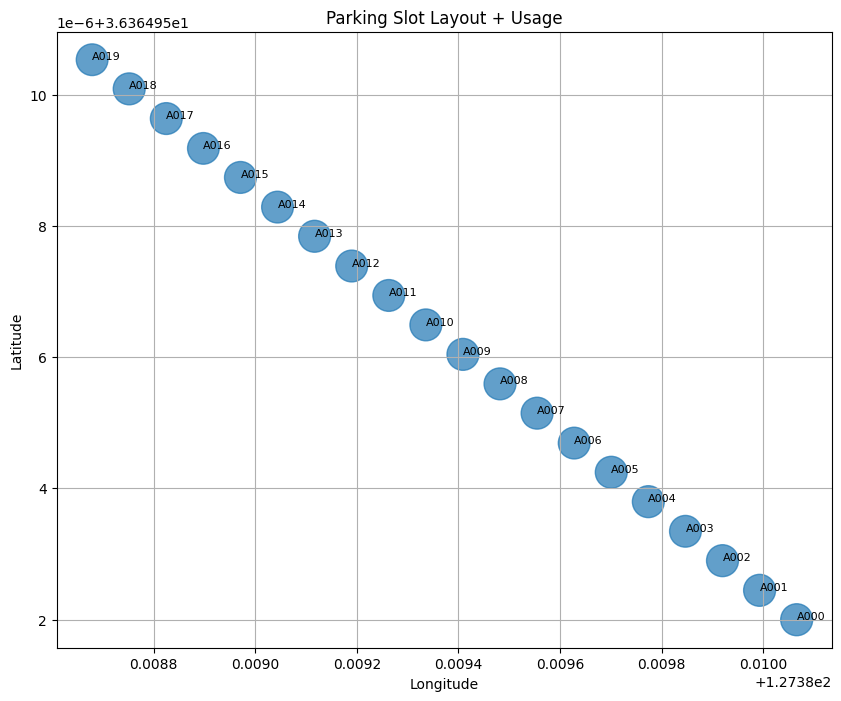

In [9]:
plot_slot_layout_usage(datasets["DT1"]["timeline"])

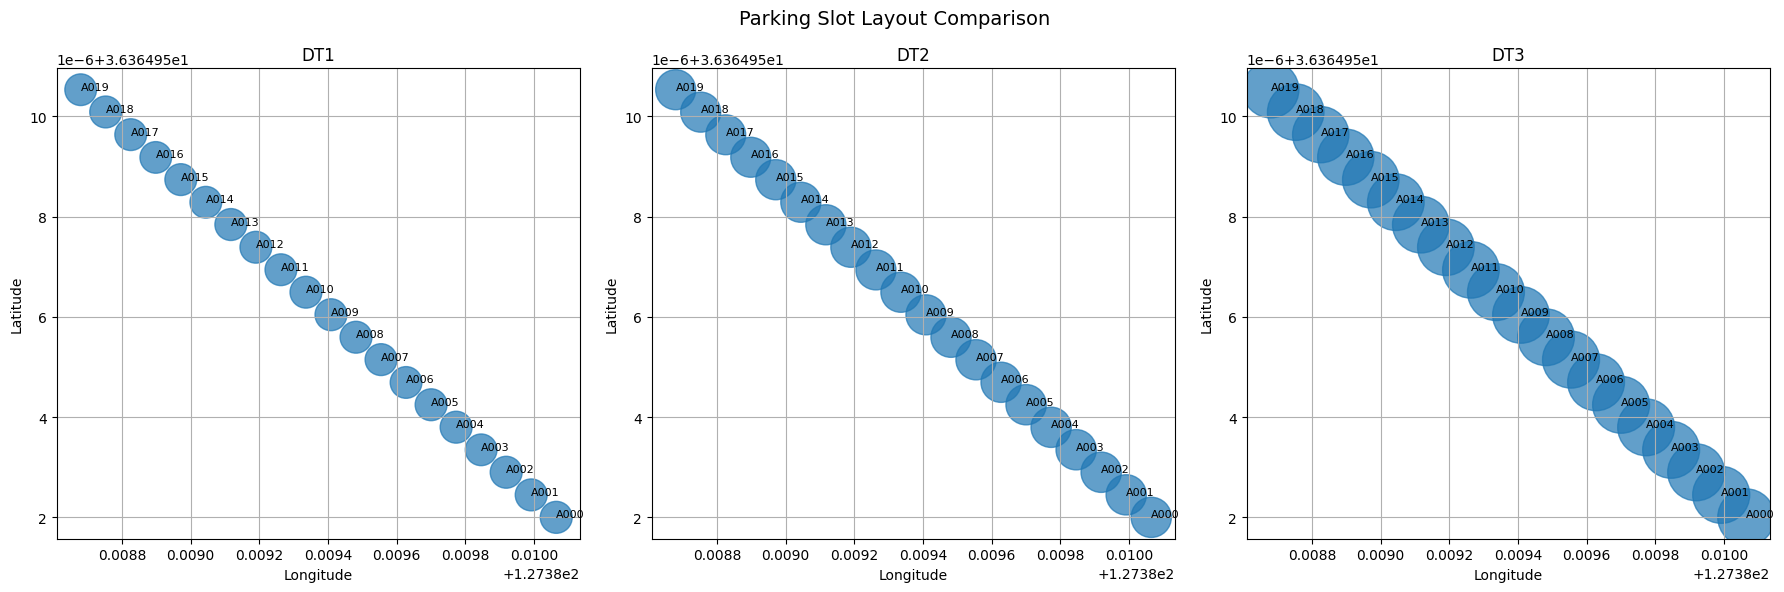

In [5]:
from analysis.slot import *

plot_all_slot_layouts(
    datasets
)

In [6]:
for client in datasets:

    timeline = datasets[client]["timeline"]

    print(client)

    print(
        timeline["lat"].min(),
        timeline["lat"].max()
    )

    print(
        timeline["lon"].min(),
        timeline["lon"].max()
    )

    print()

DT1
36.3648573914535 36.3649605488737
127.38837610992138 127.39014502443236

DT2
36.36485740759379 36.36496055021016
127.38837610583604 127.39014506613672

DT3
36.364854932132985 36.36496055296874
127.38837610719784 127.39014523465642



In [7]:
for client in datasets:

    timeline = datasets[client]["timeline"]

    slot_pos = (
        timeline
        .dropna(subset=["park_slot_id"])
        .groupby("park_slot_id")
        [["lat","lon"]]
        .mean()
    )

    print(client)

    print(
        slot_pos.head()
    )

    print()

DT1
                    lat         lon
park_slot_id                       
A000          36.364952  127.390065
A001          36.364952  127.389992
A002          36.364953  127.389920
A003          36.364953  127.389847
A004          36.364954  127.389774

DT2
                    lat         lon
park_slot_id                       
A000          36.364952  127.390065
A001          36.364952  127.389992
A002          36.364953  127.389920
A003          36.364953  127.389847
A004          36.364954  127.389774

DT3
                    lat         lon
park_slot_id                       
A000          36.364952  127.390065
A001          36.364952  127.389992
A002          36.364953  127.389920
A003          36.364953  127.389847
A004          36.364954  127.389774

